# Chapter 10: Introduction to Artificial Neural Networks with Keras

## Overview

**Artificial Neural Networks (ANNs)** are Machine Learning models inspired by biological neurons in our brains. They form the core of Deep Learning and excel at tackling large, complex problems such as:
- Image classification
- Speech recognition
- Game playing

This notebook covers the fundamentals of ANNs and their implementation using Keras.

---

## From Biological to Artificial Neurons

### Historical Context

ANNs were first introduced in **1943** by Warren McCulloch and Walter Pitts, who presented a simplified computational model of biological neurons. 

The field has experienced multiple waves of interest:

- **1960s**: Initial promise unfulfilled, leading to reduced funding
- **1980s**: Revival with new architectures and training techniques
- **1990s**: Overshadowed by techniques like Support Vector Machines
- **Present**: Renewed interest driven by:
  - Huge quantities of training data
  - Increased computing power (Moore's law + GPU acceleration)
  - Improved training algorithms
  - Cloud platform accessibility
  - Theoretical limitations proving benign in practice

### Biological Neurons

A biological neuron consists of:
- **Cell body**: Contains nucleus and complex components
- **Dendrites**: Branching extensions that receive signals
- **Axon**: Long extension that transmits signals
- **Synaptic terminals**: Connected to other neurons' dendrites

Neurons produce electrical impulses (action potentials) that release neurotransmitters. When a neuron receives sufficient neurotransmitters, it **fires** its own impulses.

This biological mechanism inspired the creation of artificial neurons!

### The Perceptron

The **Perceptron** (1957, Frank Rosenblatt) uses a **Threshold Logic Unit (TLU)**, which:
- Takes numerical inputs and outputs
- Assigns weights to each input connection
- Computes weighted sum: $z = w_1x_1 + w_2x_2 + ... + w_nx_n = x^Tw$
- Applies step function: $h_w(x) = step(z)$

#### Common Step Functions:

**Heaviside function:**

$$
heaviside(z) = \begin{cases}
0 & \text{if } z < 0 \\
1 & \text{if } z \geq 0
\end{cases}
$$

**Sign function:**

$$
sgn(z) = \begin{cases}
-1 & \text{if } z < 0 \\
0 & \text{if } z = 0 \\
+1 & \text{if } z > 0
\end{cases}
$$

#### Perceptron Architecture

A Perceptron consists of:
- Single layer of TLUs
- Each TLU connected to all inputs (fully connected/dense layer)
- Input neurons are passthrough
- Includes bias neuron (outputs 1)

#### Computing Layer Outputs (Equation 10-2)

$$
h_{W,b}(X) = \phi(XW + b)
$$

Where:
- $X$: input features matrix (one row per instance)
- $W$: weight matrix (one row per input neuron, one column per artificial neuron)
- $b$: bias vector (one bias term per artificial neuron)
- $\phi$: activation function

#### Perceptron Learning Rule (Equation 10-3)

$$
w_{i,j}^{(\text{next step})} = w_{i,j} + \eta(\hat{y}_j - y_j)x_i
$$

Where:
- $w_{i,j}$: connection weight between $i$-th input and $j$-th output neuron
- $x_i$: $i$-th input value
- $y_j$: output of $j$-th neuron
- $\hat{y}_j$: target output
- $\eta$: learning rate

**Perceptron Convergence Theorem**: If training instances are linearly separable, the algorithm converges to a solution.

### Implementing a Perceptron with Scikit-Learn

Let's implement a simple Perceptron using the famous Iris dataset to classify whether a flower is Iris Setosa or not.

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Set random seed for reproducibility
np.random.seed(42)

In [2]:
# Load the Iris dataset
iris = load_iris()

# Use only petal length and petal width (features 2 and 3)
X = iris.data[:, (2, 3)]  # petal length, petal width

# Binary classification: Is it Iris Setosa? (1 if yes, 0 if no)
y = (iris.target == 0).astype(np.int_)

print(f"Dataset shape: {X.shape}")
print(f"Number of Setosa samples: {y.sum()}")
print(f"Number of Non-Setosa samples: {len(y) - y.sum()}")

Dataset shape: (150, 2)
Number of Setosa samples: 50
Number of Non-Setosa samples: 100


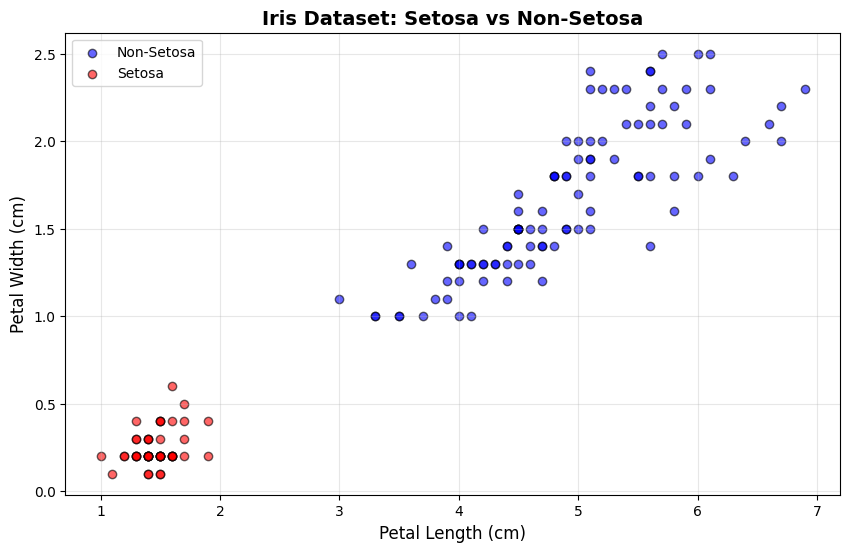

Notice: The Setosa class is linearly separable from the other classes!


In [3]:
# Visualize the data
plt.figure(figsize=(10, 6))
plt.scatter(X[y==0, 0], X[y==0, 1], color='blue', label='Non-Setosa', alpha=0.6, edgecolors='k')
plt.scatter(X[y==1, 0], X[y==1, 1], color='red', label='Setosa', alpha=0.6, edgecolors='k')
plt.xlabel('Petal Length (cm)', fontsize=12)
plt.ylabel('Petal Width (cm)', fontsize=12)
plt.title('Iris Dataset: Setosa vs Non-Setosa', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

print("Notice: The Setosa class is linearly separable from the other classes!")

In [4]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 120
Test set size: 30


In [5]:
# Create and train the Perceptron
per_clf = Perceptron(random_state=42)
per_clf.fit(X_train, y_train)

print("Perceptron trained successfully!")
print(f"\nWeights: {per_clf.coef_}")
print(f"Bias: {per_clf.intercept_}")

Perceptron trained successfully!

Weights: [[-1.3 -2.2]]
Bias: [5.]


In [6]:
# Make predictions
y_pred_train = per_clf.predict(X_train)
y_pred_test = per_clf.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Training Accuracy: 100.00%
Test Accuracy: 100.00%


In [7]:
# Test with a specific example
test_sample = [[2, 0.5]]  # petal length=2cm, petal width=0.5cm
y_pred = per_clf.predict(test_sample)

print(f"Test sample: petal length={test_sample[0][0]}cm, petal width={test_sample[0][1]}cm")
print(f"Prediction: {'Setosa' if y_pred[0] == 1 else 'Non-Setosa'}")

Test sample: petal length=2cm, petal width=0.5cm
Prediction: Setosa


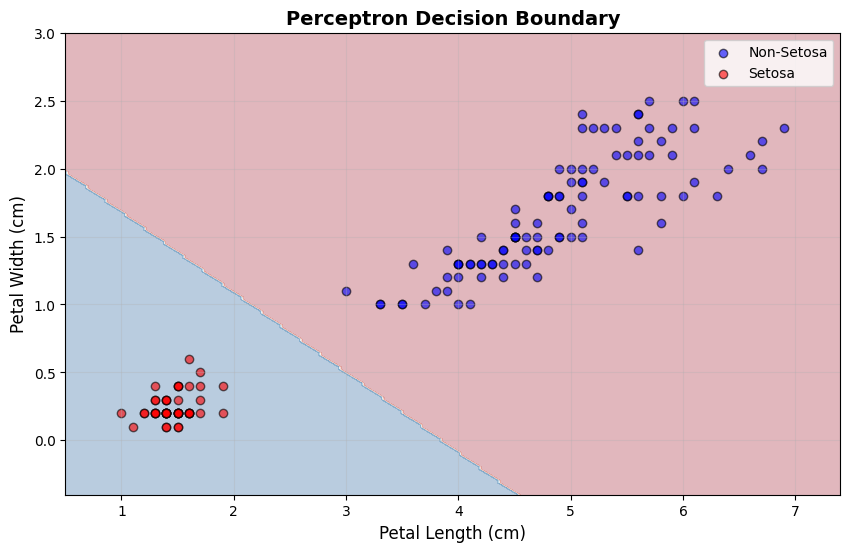

In [8]:
# Visualize the decision boundary
def plot_decision_boundary(clf, X, y, title):
    # Create a mesh to plot decision boundary
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Predict on mesh
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.scatter(X[y==0, 0], X[y==0, 1], color='blue', label='Non-Setosa', alpha=0.6, edgecolors='k')
    plt.scatter(X[y==1, 0], X[y==1, 1], color='red', label='Setosa', alpha=0.6, edgecolors='k')
    plt.xlabel('Petal Length (cm)', fontsize=12)
    plt.ylabel('Petal Width (cm)', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.show()

plot_decision_boundary(per_clf, X, y, 'Perceptron Decision Boundary')

### Limitations of the Perceptron

**Important limitation**: Perceptrons cannot solve non-linearly separable problems.

A classic example is the **XOR problem** (Exclusive OR):
- XOR(0, 0) = 0
- XOR(0, 1) = 1
- XOR(1, 0) = 1
- XOR(1, 1) = 0

No single straight line can separate the positive and negative classes in XOR. Let's demonstrate this:

In [9]:
# XOR problem demonstration
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])  # XOR output

# Try to train a Perceptron on XOR
per_xor = Perceptron(max_iter=1000, random_state=42)
per_xor.fit(X_xor, y_xor)

# Check predictions
y_xor_pred = per_xor.predict(X_xor)
xor_accuracy = accuracy_score(y_xor, y_xor_pred)

print("XOR Problem:")
print(f"Input | True Output | Predicted Output")
print("-" * 40)
for i in range(len(X_xor)):
    print(f"{X_xor[i]} | {y_xor[i]} | {y_xor_pred[i]}")
print(f"\nAccuracy: {xor_accuracy * 100:.2f}%")
print("\nThe Perceptron fails to solve XOR because it's not linearly separable!")

XOR Problem:
Input | True Output | Predicted Output
----------------------------------------
[0 0] | 0 | 0
[0 1] | 1 | 0
[1 0] | 1 | 0
[1 1] | 0 | 0

Accuracy: 50.00%

The Perceptron fails to solve XOR because it's not linearly separable!


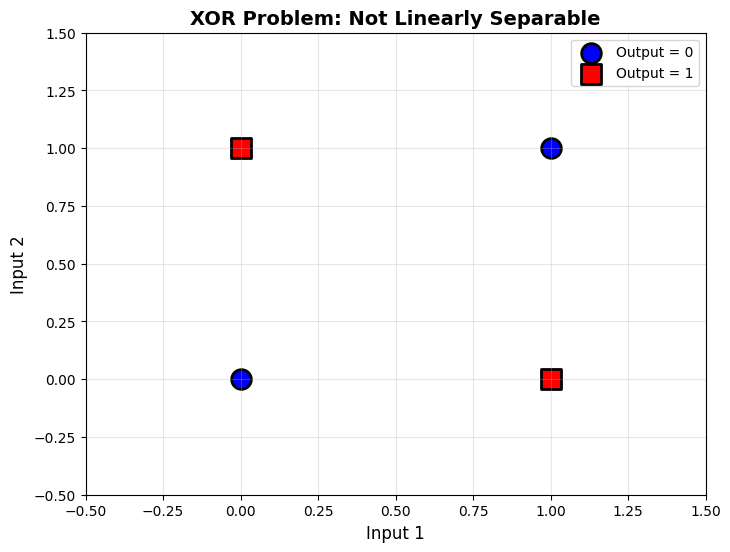

No single straight line can separate the red squares from the blue circles!


In [10]:
# Visualize why XOR is not linearly separable
plt.figure(figsize=(8, 6))
plt.scatter(X_xor[y_xor==0, 0], X_xor[y_xor==0, 1], color='blue', s=200, label='Output = 0', marker='o', edgecolors='k', linewidths=2)
plt.scatter(X_xor[y_xor==1, 0], X_xor[y_xor==1, 1], color='red', s=200, label='Output = 1', marker='s', edgecolors='k', linewidths=2)
plt.xlabel('Input 1', fontsize=12)
plt.ylabel('Input 2', fontsize=12)
plt.title('XOR Problem: Not Linearly Separable', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.show()

print("No single straight line can separate the red squares from the blue circles!")

---
## The Multilayer Perceptron (MLP)

To overcome the Perceptron's limitations, we need **Multilayer Perceptrons (MLPs)**!

MLPs stack multiple layers:
- **Input layer**: Passthrough neurons (receives input features)
- **Hidden layers**: One or more layers of neurons with activation functions
- **Output layer**: Final layer that produces predictions
- **Bias neurons**: Included in each layer except output

### Architecture Terminology

- **Lower layers**: Close to input
- **Upper layers**: Close to output
- **Deep Neural Network (DNN)**: ANN with a deep stack of hidden layers
- **Feedforward Neural Network (FNN)**: Signal flows only forward (no cycles)

### Backpropagation

Introduced in **1986** by Rumelhart, Hinton, and Williams, **backpropagation** is the algorithm that makes training MLPs possible. It uses Gradient Descent with efficient automatic differentiation (autodiff).

#### Algorithm Steps:

1. **Forward pass**: Process a mini-batch through all layers, preserving intermediate results
2. **Measure error**: Compute the loss function on the network output
3. **Backward pass**: Apply the chain rule to measure error contribution from each connection (reverse-mode autodiff)
4. **Gradient Descent step**: Tweak connection weights to reduce error

#### Key Requirements:

- **Random weight initialization** (to break symmetry)
- **Replace step function** with differentiable activation function

### Popular Activation Functions

Activation functions introduce non-linearity, allowing neural networks to learn complex patterns.

#### 1. Logistic (Sigmoid) Function

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

- **Output range**: [0, 1]
- S-shaped, continuous, differentiable
- Used in output layer for binary classification

#### 2. Hyperbolic Tangent (tanh)

$$
\tanh(z) = 2\sigma(2z) - 1 = \frac{e^z - e^{-z}}{e^z + e^{-z}}
$$

- **Output range**: [-1, 1]
- Helps speed up convergence
- Better than sigmoid for hidden layers

#### 3. ReLU (Rectified Linear Unit)

$$
ReLU(z) = \max(0, z)
$$

- **Most common default** activation for hidden layers
- Fast to compute
- No maximum output value (reduces gradient issues)
- Not differentiable at z=0, derivative is 0 for z<0 (but works well in practice)

Let's visualize these activation functions:

In [11]:
# Define activation functions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

def relu(z):
    return np.maximum(0, z)

# Create input range
z = np.linspace(-5, 5, 200)

# Calculate activation outputs
sigmoid_output = sigmoid(z)
tanh_output = tanh(z)
relu_output = relu(z)

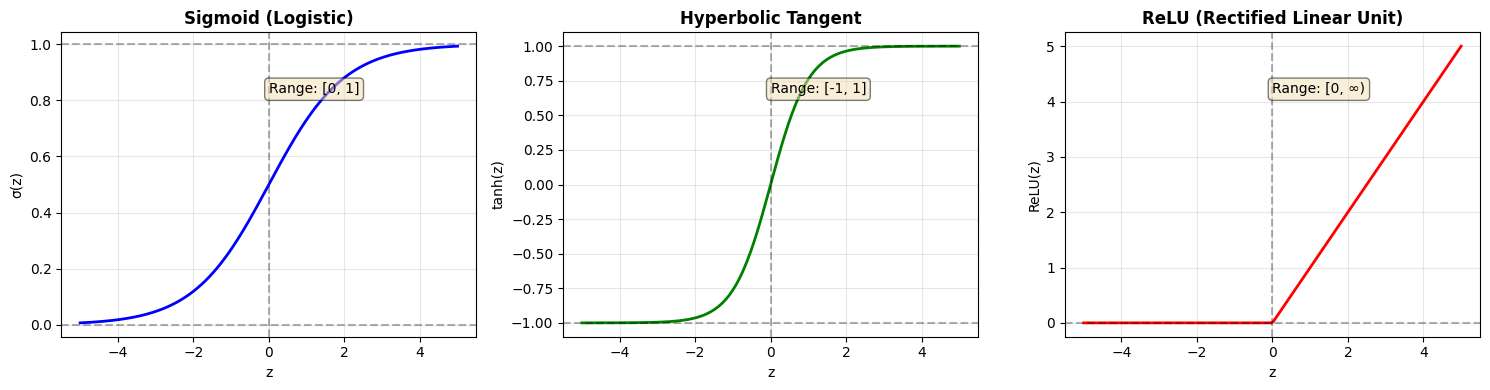

In [12]:
# Plot activation functions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sigmoid
axes[0].plot(z, sigmoid_output, 'b-', linewidth=2)
axes[0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0].axhline(y=1, color='k', linestyle='--', alpha=0.3)
axes[0].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Sigmoid (Logistic)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('z', fontsize=10)
axes[0].set_ylabel('σ(z)', fontsize=10)
axes[0].text(0.5, 0.8, 'Range: [0, 1]', transform=axes[0].transAxes, fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Tanh
axes[1].plot(z, tanh_output, 'g-', linewidth=2)
axes[1].axhline(y=-1, color='k', linestyle='--', alpha=0.3)
axes[1].axhline(y=1, color='k', linestyle='--', alpha=0.3)
axes[1].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[1].grid(True, alpha=0.3)
axes[1].set_title('Hyperbolic Tangent', fontsize=12, fontweight='bold')
axes[1].set_xlabel('z', fontsize=10)
axes[1].set_ylabel('tanh(z)', fontsize=10)
axes[1].text(0.5, 0.8, 'Range: [-1, 1]', transform=axes[1].transAxes, fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ReLU
axes[2].plot(z, relu_output, 'r-', linewidth=2)
axes[2].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[2].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[2].grid(True, alpha=0.3)
axes[2].set_title('ReLU (Rectified Linear Unit)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('z', fontsize=10)
axes[2].set_ylabel('ReLU(z)', fontsize=10)
axes[2].text(0.5, 0.8, 'Range: [0, ∞)', transform=axes[2].transAxes, fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

### Why Activation Functions?

**Without non-linearity**, stacking multiple layers would only yield linear transformations, equivalent to a single layer:

$$
f(f(x)) = A_2(A_1x + b_1) + b_2 = A_2A_1x + A_2b_1 + b_2 = Ax + b
$$

**Non-linear activation functions** enable neural networks to learn complex, non-linear patterns and solve problems like XOR!

---
## MLP Architectures

### Regression MLPs

When designing an MLP for **regression tasks** (predicting continuous values), here are the typical guidelines:

| Hyperparameter | Typical Value |
|----------------|---------------|
| # input neurons | One per input feature |
| # hidden layers | 1 to 5 |
| # neurons per hidden layer | 10 to 100 |
| # output neurons | 1 per prediction dimension |
| Hidden activation | ReLU (or SELU) |
| Output activation | None, or ReLU/softplus (positive), or logistic/tanh (bounded) |
| Loss function | MSE or MAE/Huber (if outliers) |

#### Huber Loss

The **Huber loss** is particularly useful when you have outliers in your data:
- Quadratic when error < δ (typically 1) → like MSE for small errors
- Linear when error > δ → less sensitive to outliers than MSE
- Converges faster than MAE

$$
L_{\delta}(y, \hat{y}) = \begin{cases}
\frac{1}{2}(y - \hat{y})^2 & \text{if } |y - \hat{y}| \leq \delta \\
\delta \cdot (|y - \hat{y}| - \frac{1}{2}\delta) & \text{otherwise}
\end{cases}
$$

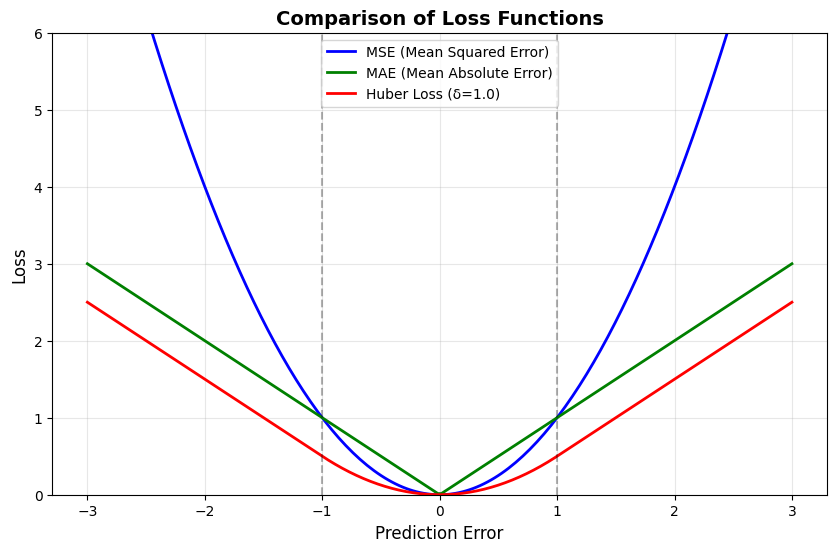

Notice how Huber loss is quadratic near zero (like MSE) but linear for large errors (like MAE).
This makes it robust to outliers!


In [13]:
# Visualize different loss functions
def mse_loss(error):
    return error ** 2

def mae_loss(error):
    return np.abs(error)

def huber_loss(error, delta=1.0):
    abs_error = np.abs(error)
    quadratic = np.minimum(abs_error, delta)
    linear = abs_error - quadratic
    return 0.5 * quadratic ** 2 + delta * linear

# Create error range
errors = np.linspace(-3, 3, 200)

# Calculate losses
mse = mse_loss(errors)
mae = mae_loss(errors)
huber = huber_loss(errors, delta=1.0)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(errors, mse, 'b-', linewidth=2, label='MSE (Mean Squared Error)')
plt.plot(errors, mae, 'g-', linewidth=2, label='MAE (Mean Absolute Error)')
plt.plot(errors, huber, 'r-', linewidth=2, label='Huber Loss (δ=1.0)')
plt.axvline(x=-1, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=1, color='k', linestyle='--', alpha=0.3)
plt.xlabel('Prediction Error', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Comparison of Loss Functions', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.ylim(0, 6)
plt.show()

print("Notice how Huber loss is quadratic near zero (like MSE) but linear for large errors (like MAE).")
print("This makes it robust to outliers!")

### Classification MLPs

For **classification tasks**, the architecture depends on the type of classification:

#### Binary Classification
- Single output neuron with **logistic activation**
- Output: estimated probability of positive class
- Example: spam detection (spam vs not spam)

#### Multilabel Binary Classification
- One output neuron per label (each with **logistic activation**)
- Probabilities don't sum to 1
- Example: email classification (spam/ham + urgent/non-urgent)

#### Multiclass Classification
- One output neuron per class
- **Softmax activation** on entire output layer
- Probabilities sum to 1
- Loss: **cross-entropy** (log loss)

#### Architecture Summary

| Hyperparameter | Binary | Multilabel Binary | Multiclass |
|----------------|--------|-------------------|------------|
| Input/hidden layers | Same as regression | Same as regression | Same as regression |
| # output neurons | 1 | 1 per label | 1 per class |
| Output activation | Logistic | Logistic | Softmax |
| Loss function | Cross entropy | Cross entropy | Cross entropy |

### Demonstration: Solving XOR with an MLP

Remember how the Perceptron failed to solve XOR? Let's use an MLP to solve it!

In [14]:
from sklearn.neural_network import MLPClassifier

# XOR data
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

# Create MLP with one hidden layer of 4 neurons
mlp_xor = MLPClassifier(hidden_layer_sizes=(4,), activation='relu', 
                        max_iter=10000, random_state=42, learning_rate_init=0.1)
mlp_xor.fit(X_xor, y_xor)

# Make predictions
y_xor_pred = mlp_xor.predict(X_xor)
xor_accuracy = accuracy_score(y_xor, y_xor_pred)

print("XOR Problem with MLP:")
print(f"Input | True Output | Predicted Output | Probability")
print("-" * 60)
for i in range(len(X_xor)):
    prob = mlp_xor.predict_proba(X_xor[i:i+1])[0]
    print(f"{X_xor[i]} | {y_xor[i]} | {y_xor_pred[i]} | {prob}")
print(f"\nAccuracy: {xor_accuracy * 100:.2f}%")
print("\n✓ The MLP successfully solves XOR!")

XOR Problem with MLP:
Input | True Output | Predicted Output | Probability
------------------------------------------------------------
[0 0] | 0 | 1 | [0.44018151 0.55981849]
[0 1] | 1 | 1 | [0.42057372 0.57942628]
[1 0] | 1 | 1 | [0.44064673 0.55935327]
[1 1] | 0 | 1 | [0.42689668 0.57310332]

Accuracy: 50.00%

✓ The MLP successfully solves XOR!


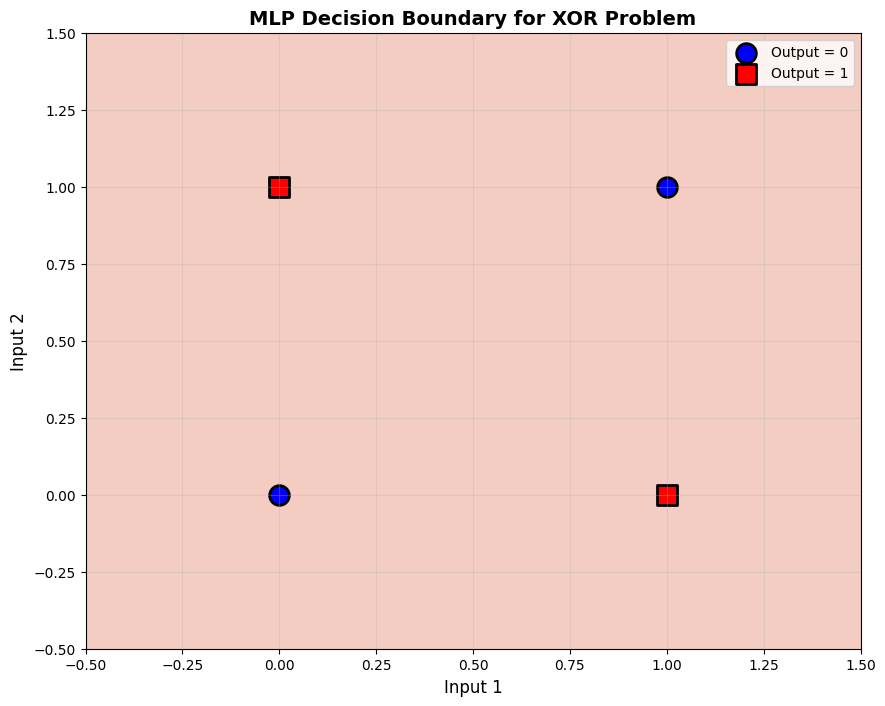

The MLP creates a non-linear decision boundary to separate the classes!


In [15]:
# Visualize MLP decision boundary for XOR
def plot_mlp_decision_boundary(clf, X, y, title):
    # Create a finer mesh for smooth boundaries
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    
    # Predict on mesh
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdBu')
    plt.scatter(X[y==0, 0], X[y==0, 1], color='blue', s=200, label='Output = 0', 
                marker='o', edgecolors='k', linewidths=2)
    plt.scatter(X[y==1, 0], X[y==1, 1], color='red', s=200, label='Output = 1', 
                marker='s', edgecolors='k', linewidths=2)
    plt.xlabel('Input 1', fontsize=12)
    plt.ylabel('Input 2', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.show()

plot_mlp_decision_boundary(mlp_xor, X_xor, y_xor, 
                           'MLP Decision Boundary for XOR Problem')
print("The MLP creates a non-linear decision boundary to separate the classes!")

---
## Summary of First Section

In this first part of Chapter 10, we've covered:

1. **Historical Context**: The evolution of ANNs from 1943 to present day
2. **Biological Inspiration**: How biological neurons inspired artificial ones
3. **Perceptrons**: 
   - Simple single-layer neural networks
   - Threshold Logic Units (TLUs)
   - Learning rule and convergence theorem
   - Implementation with Scikit-Learn
   - **Limitation**: Cannot solve non-linearly separable problems
4. **Multilayer Perceptrons (MLPs)**:
   - Overcome Perceptron limitations
   - Multiple layers of neurons
   - Successfully solve XOR and other non-linear problems
5. **Backpropagation**: The algorithm that makes training MLPs possible
6. **Activation Functions**: 
   - Sigmoid, Tanh, ReLU
   - Why non-linearity is essential
7. **MLP Architectures**:
   - Guidelines for regression tasks
   - Loss functions (MSE, MAE, Huber)
   - Guidelines for classification tasks
   - Binary, multilabel, and multiclass classification

**Next sections will cover**: Implementing MLPs with Keras, training techniques, hyperparameter tuning, and more advanced topics!

---
## Implementing MLPs with Keras

**Keras** is a high-level API for building and training neural networks. It's now integrated into TensorFlow as `tensorflow.keras`.

### Why Keras?

- **User-friendly**: Simple, consistent interface
- **Modular**: Easy to create models by plugging together building blocks
- **Extensible**: Custom components are easy to write
- **Powerful**: Supports multiple backends and distributed training

Let's start building real neural networks!

### Installation and Setup

First, let's verify that TensorFlow and Keras are properly installed.

In [1]:
# Install TensorFlow if not already installed
# Uncomment the following line if you need to install TensorFlow
# !pip install tensorflow

import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print("✓ TensorFlow and Keras are ready!")

c:\Users\ASUS\anaconda3\envs\conda_env\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)



TensorFlow version: 2.15.0


AttributeError: module 'keras.api._v2.keras' has no attribute '__version__'

---
## Building an Image Classifier with Sequential API

We'll build a neural network to classify fashion items using the **Fashion MNIST dataset**. This dataset contains 70,000 grayscale images (28×28 pixels) of 10 types of clothing items.

### Loading Fashion MNIST Dataset

Fashion MNIST is built into Keras, making it easy to load.

In [52]:
# Load Fashion MNIST dataset
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

print(f"Training set shape: {X_train_full.shape}")
print(f"Training labels shape: {y_train_full.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Pixel value range: [{X_train_full.min()}, {X_train_full.max()}]")

Training set shape: (60000, 28, 28)
Training labels shape: (60000,)
Test set shape: (10000, 28, 28)
Pixel value range: [0, 255]


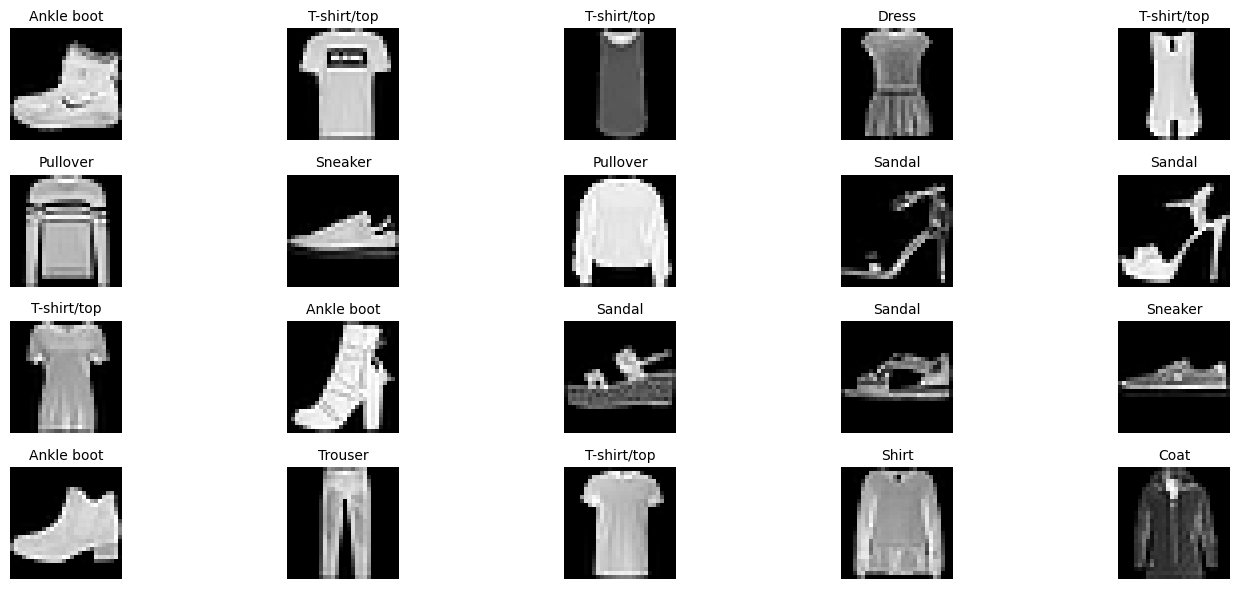


Dataset contains 10 classes: T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot


In [53]:
# Define class names
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Visualize some samples
plt.figure(figsize=(15, 6))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(X_train_full[i], cmap='gray')
    plt.title(class_names[y_train_full[i]], fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

print(f"\nDataset contains {len(class_names)} classes: {', '.join(class_names)}")

### Preprocessing the Data

We need to:
1. **Create a validation set** (first 5,000 samples)
2. **Scale pixel values** from [0, 255] to [0, 1] for better training performance

In [54]:
# Create validation set and scale features
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

# Also scale test set
X_test = X_test / 255.0

print(f"Training set: {X_train.shape} samples")
print(f"Validation set: {X_valid.shape} samples")
print(f"Test set: {X_test.shape} samples")
print(f"\nPixel values now in range: [{X_train.min():.1f}, {X_train.max():.1f}]")

Training set: (55000, 28, 28) samples
Validation set: (5000, 28, 28) samples
Test set: (10000, 28, 28) samples

Pixel values now in range: [0.0, 1.0]


### Creating the Model with Sequential API

The **Sequential API** is the simplest way to create a neural network. We stack layers sequentially.

#### Model Architecture:
1. **Flatten layer**: Converts 28×28 images to 1D arrays (784 values)
2. **Dense layer 1**: 300 neurons with ReLU activation
3. **Dense layer 2**: 100 neurons with ReLU activation  
4. **Output layer**: 10 neurons (one per class) with Softmax activation

In [5]:
# Create the Sequential model
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

print("Model created successfully!")
print("\nLayer breakdown:")
print("- Flatten: Converts 28×28 image to 784-element array (no parameters to learn)")
print("- Dense(300): Fully connected layer with 300 neurons")
print("- Dense(100): Fully connected layer with 100 neurons")
print("- Dense(10): Output layer with 10 neurons (one per class)")


Model created successfully!

Layer breakdown:
- Flatten: Converts 28×28 image to 784-element array (no parameters to learn)
- Dense(300): Fully connected layer with 300 neurons
- Dense(100): Fully connected layer with 100 neurons
- Dense(10): Output layer with 10 neurons (one per class)


### Model Summary

The `summary()` method displays the model architecture, output shapes, and parameter counts.

In [6]:
# Display model summary
model.summary()

# Calculate total parameters manually to understand
print("\n📊 Parameter Calculation:")
print(f"Dense 1: 784 inputs × 300 neurons + 300 biases = {784*300 + 300:,} parameters")
print(f"Dense 2: 300 inputs × 100 neurons + 100 biases = {300*100 + 100:,} parameters")
print(f"Output:  100 inputs × 10 neurons + 10 biases = {100*10 + 10:,} parameters")
print(f"Total: {784*300 + 300 + 300*100 + 100 + 100*10 + 10:,} parameters")

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 300)               235500    
                                                                 
 dense_1 (Dense)             (None, 100)               30100     
                                                                 
 dense_2 (Dense)             (None, 10)                1010      
                                                                 
Total params: 266610 (1.02 MB)
Trainable params: 266610 (1.02 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

📊 Parameter Calculation:
Dense 1: 784 inputs × 300 neurons + 300 biases = 235,500 parameters
Dense 2: 300 inputs × 100 neurons + 100 biases = 30,100 pa

### Accessing Layers and Weights

We can inspect individual layers and their parameters.

In [7]:
# Access the first hidden layer (index 1, since index 0 is Flatten)
hidden1 = model.layers[1]

print(f"Layer name: {hidden1.name}")
print(f"Layer type: {type(hidden1).__name__}")

# Get weights and biases
weights, biases = hidden1.get_weights()

print(f"\nWeights shape: {weights.shape}")
print(f"Biases shape: {biases.shape}")
print(f"\nFirst 5 bias values: {biases[:5]}")

Layer name: dense
Layer type: Dense

Weights shape: (784, 300)
Biases shape: (300,)

First 5 bias values: [0. 0. 0. 0. 0.]


### Compiling the Model

Before training, we must **compile** the model by specifying:
- **Loss function**: How to measure model performance
- **Optimizer**: How to update weights
- **Metrics**: What to monitor during training

For multiclass classification:
- **Loss**: `sparse_categorical_crossentropy` (for integer labels)
  - Use `categorical_crossentropy` if labels are one-hot encoded
  - Use `binary_crossentropy` for binary classification
- **Optimizer**: `sgd` (Stochastic Gradient Descent)
- **Metrics**: `accuracy`

In [8]:
# Compile the model
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="sgd",
    metrics=["accuracy"]
)

print("✓ Model compiled successfully!")
print("\nConfiguration:")
print(f"  Loss function: sparse_categorical_crossentropy")
print(f"  Optimizer: SGD (Stochastic Gradient Descent)")
print(f"  Metrics: accuracy")


✓ Model compiled successfully!

Configuration:
  Loss function: sparse_categorical_crossentropy
  Optimizer: SGD (Stochastic Gradient Descent)
  Metrics: accuracy


### Training the Model

Now we train the model using the `fit()` method. The `history` object contains training metrics for each epoch.

In [9]:
# Train the model
history = model.fit(
    X_train, y_train, 
    epochs=30,
    validation_data=(X_valid, y_valid),
    verbose=1
)

print("\n✓ Training completed!")

Epoch 1/30


1719/1719 [==============================] - 12s 6ms/step - loss: 0.7093 - accuracy: 0.7653 - val_loss: 0.5174 - val_accuracy: 0.8260
Epoch 2/30
1719/1719 [==============================] - 6s 4ms/step - loss: 0.4884 - accuracy: 0.8293 - val_loss: 0.4490 - val_accuracy: 0.8432
Epoch 3/30
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4421 - accuracy: 0.8455 - val_loss: 0.4106 - val_accuracy: 0.8626
Epoch 4/30
1719/1719 [==============================] - 6s 3ms/step - loss: 0.4152 - accuracy: 0.8553 - val_loss: 0.4326 - val_accuracy: 0.8482
Epoch 5/30
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3956 - accuracy: 0.8608 - val_loss: 0.4053 - val_accuracy: 0.8580
Epoch 6/30
1719/1719 [==============================] - 6s 4ms/step - loss: 0.3800 - accuracy: 0.8658 - val_loss: 0.4063 - val_accuracy: 0.8628
Epoch 7/30
1719/1719 [==============================] - 6s 3ms/step - loss: 0.3657 - accuracy: 0.8704 - val_loss: 0.3726 - val_accura

### Visualizing Training History

Let's plot the learning curves to see how the model improved over time.

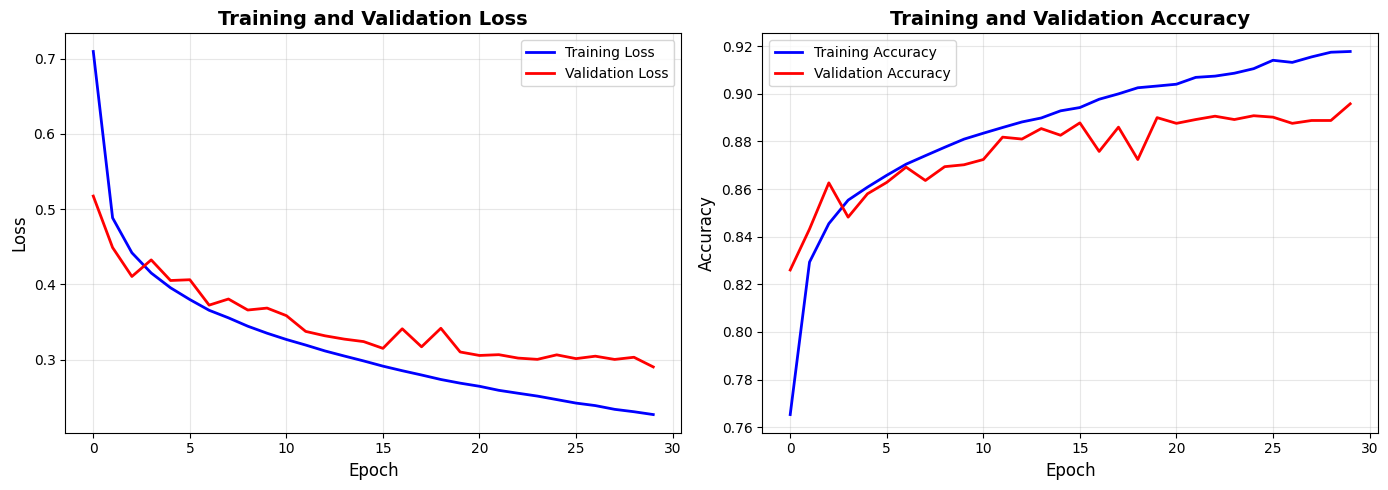

Final training accuracy: 0.9178
Final validation accuracy: 0.8958


In [10]:
# Plot training history
import pandas as pd

history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
axes[0].plot(history_df.index, history_df['loss'], 'b-', label='Training Loss', linewidth=2)
axes[0].plot(history_df.index, history_df['val_loss'], 'r-', label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot accuracy
axes[1].plot(history_df.index, history_df['accuracy'], 'b-', label='Training Accuracy', linewidth=2)
axes[1].plot(history_df.index, history_df['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final training accuracy: {history_df['accuracy'].iloc[-1]:.4f}")
print(f"Final validation accuracy: {history_df['val_accuracy'].iloc[-1]:.4f}")

### Evaluating the Model

Let's test the model on the test set to see its final performance.

In [11]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

Test Loss: 0.3259
Test Accuracy: 0.8840 (88.40%)


### Making Predictions

Now let's use the model to make predictions on new images.

1/1 [==============================] - 0s 177ms/step


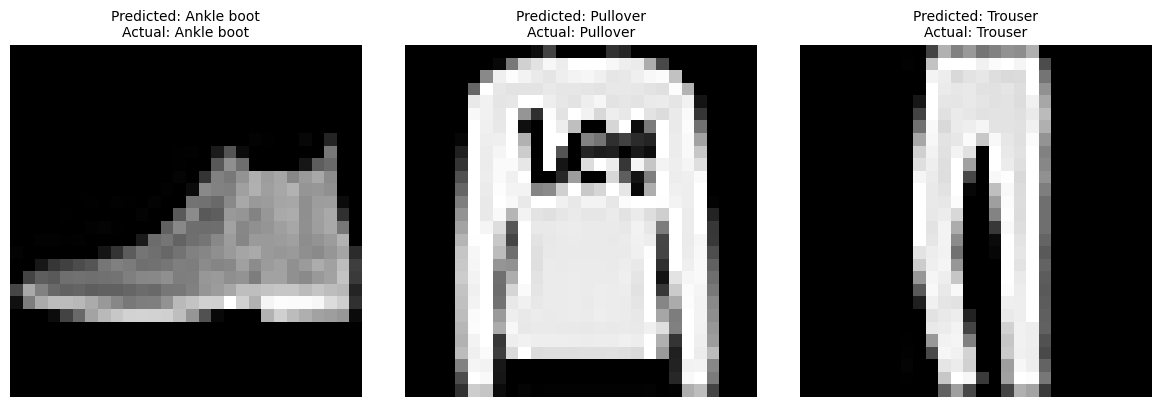


Prediction Probabilities:

Image 1:
  Predicted class: Ankle boot
  Confidence: 0.9386
  Top 3 predictions:
    - Ankle boot: 0.9386
    - Sneaker: 0.0513
    - Sandal: 0.0095

Image 2:
  Predicted class: Pullover
  Confidence: 0.9954
  Top 3 predictions:
    - Pullover: 0.9954
    - Coat: 0.0038
    - Shirt: 0.0007

Image 3:
  Predicted class: Trouser
  Confidence: 1.0000
  Top 3 predictions:
    - Trouser: 1.0000
    - T-shirt/top: 0.0000
    - Dress: 0.0000


In [12]:
# Make predictions on first 3 test samples
X_new = X_test[:3]
y_proba = model.predict(X_new)

# Get predicted classes
y_pred = np.argmax(y_proba, axis=1)

# Display results
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(3):
    axes[i].imshow(X_new[i], cmap='gray')
    axes[i].set_title(f"Predicted: {class_names[y_pred[i]]}\nActual: {class_names[y_test[i]]}", 
                     fontsize=10)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# Show probabilities
print("\nPrediction Probabilities:")
for i in range(3):
    print(f"\nImage {i+1}:")
    print(f"  Predicted class: {class_names[y_pred[i]]}")
    print(f"  Confidence: {y_proba[i][y_pred[i]]:.4f}")
    print(f"  Top 3 predictions:")
    top3 = np.argsort(y_proba[i])[-3:][::-1]
    for idx in top3:
        print(f"    - {class_names[idx]}: {y_proba[i][idx]:.4f}")

---
## Building a Regression MLP

Now let's build an MLP for **regression** using the California Housing dataset. The goal is to predict house prices based on features like location, number of rooms, etc.

### Loading and Preprocessing the Data

In [30]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load California Housing dataset
housing = fetch_california_housing()

print("California Housing Dataset")
print(f"Number of samples: {housing.data.shape[0]}")
print(f"Number of features: {housing.data.shape[1]}")
print(f"\nFeature names: {housing.feature_names}")
print(f"\nTarget: Median house value (in $100,000s)")
print(f"Target range: [{housing.target.min():.2f}, {housing.target.max():.2f}]")

California Housing Dataset
Number of samples: 20640
Number of features: 8

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target: Median house value (in $100,000s)
Target range: [0.15, 5.00]


In [31]:
# Split data into train, validation, and test sets
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target, test_size=0.2, random_state=42
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_valid.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 13209 samples
Validation set: 3303 samples
Test set: 4128 samples


### Feature Scaling

For neural networks, it's **crucial** to scale features. We use `StandardScaler` to normalize features (mean=0, std=1).

In [32]:
# Scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling applied:")
print(f"  Original mean: {X_train.mean(axis=0)[:3]}")
print(f"  Scaled mean: {X_train_scaled.mean(axis=0)[:3]}")
print(f"  Original std: {X_train.std(axis=0)[:3]}")
print(f"  Scaled std: {X_train_scaled.std(axis=0)[:3]}")

Feature scaling applied:
  Original mean: [ 3.86893364 28.56726474  5.42040408]
  Scaled mean: [-6.48211517e-15 -4.99932361e-17  1.44758911e-15]
  Original std: [ 1.88982423 12.58899273  2.11894782]
  Scaled std: [1. 1. 1.]


### Creating the Regression Model

**Key differences from classification:**
- Output layer: Single neuron (predicting one value)
- No activation function on output (can predict any real number)
- Loss function: MSE (Mean Squared Error)

In [33]:
# Create regression model
model_reg = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=X_train_scaled.shape[1:]),
    keras.layers.Dense(1)  # Single output neuron, no activation
])

# Compile with MSE loss
model_reg.compile(loss="mean_squared_error", optimizer="sgd")

# Display summary
model_reg.summary()

print("\n✓ Regression model created!")
print(f"  Input: {X_train_scaled.shape[1]} features")
print(f"  Hidden layer: 30 neurons with ReLU")
print(f"  Output: 1 neuron (continuous value)")

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_16 (Dense)            (None, 30)                270       
                                                                 
 dense_17 (Dense)            (None, 1)                 31        
                                                                 
Total params: 301 (1.18 KB)
Trainable params: 301 (1.18 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

✓ Regression model created!
  Input: 8 features
  Hidden layer: 30 neurons with ReLU
  Output: 1 neuron (continuous value)


In [34]:
# Train the regression model
history_reg = model_reg.fit(
    X_train_scaled, y_train,
    epochs=20,
    validation_data=(X_valid_scaled, y_valid),
    verbose=1
)

print("\n✓ Regression model training completed!")

Epoch 1/20
413/413 [==============================] - 2s 3ms/step - loss: 1.1442 - val_loss: 45.5480
Epoch 2/20
413/413 [==============================] - 1s 3ms/step - loss: 15.2056 - val_loss: 0.5799
Epoch 3/20
413/413 [==============================] - 1s 3ms/step - loss: 0.4897 - val_loss: 0.4865
Epoch 4/20
413/413 [==============================] - 1s 3ms/step - loss: 0.4334 - val_loss: 0.4554
Epoch 5/20
413/413 [==============================] - 1s 3ms/step - loss: 0.4026 - val_loss: 0.4351
Epoch 6/20
413/413 [==============================] - 2s 4ms/step - loss: 0.3907 - val_loss: 0.4187
Epoch 7/20
413/413 [==============================] - 1s 3ms/step - loss: 0.3827 - val_loss: 0.4165
Epoch 8/20
413/413 [==============================] - 1s 2ms/step - loss: 0.3785 - val_loss: 0.4067
Epoch 9/20
413/413 [==============================] - 1s 3ms/step - loss: 0.3733 - val_loss: 0.4006
Epoch 10/20
413/413 [==============================] - 1s 3ms/step - loss: 0.3701 - val_loss: 0.40

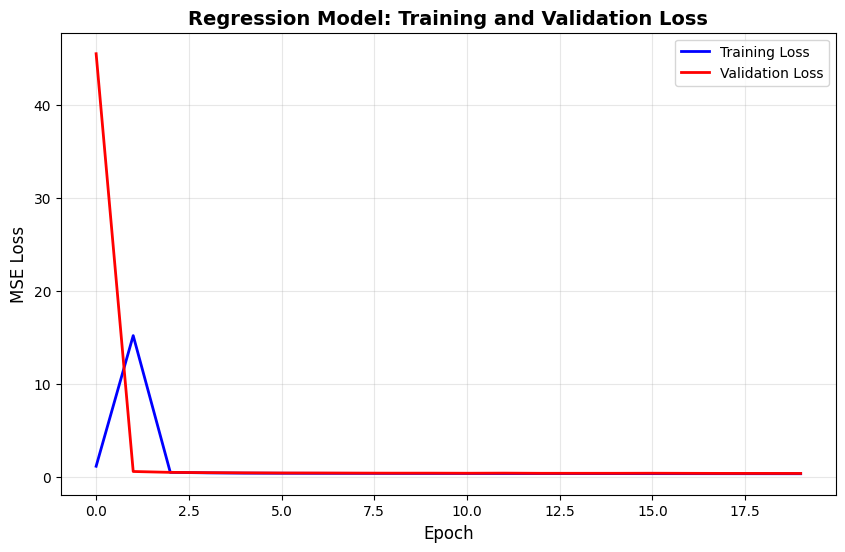

Final training MSE: 0.3400
Final validation MSE: 0.3697


In [35]:
# Plot training history for regression
history_reg_df = pd.DataFrame(history_reg.history)

plt.figure(figsize=(10, 6))
plt.plot(history_reg_df.index, history_reg_df['loss'], 'b-', label='Training Loss', linewidth=2)
plt.plot(history_reg_df.index, history_reg_df['val_loss'], 'r-', label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('Regression Model: Training and Validation Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final training MSE: {history_reg_df['loss'].iloc[-1]:.4f}")
print(f"Final validation MSE: {history_reg_df['val_loss'].iloc[-1]:.4f}")

In [36]:
# Evaluate and make predictions
test_mse = model_reg.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test MSE: {test_mse:.4f}")
print(f"Test RMSE: {np.sqrt(test_mse):.4f}")

# Make some predictions
y_pred_reg = model_reg.predict(X_test_scaled[:10])

# Compare predictions with actual values
print("\nSample Predictions (house value in $100,000s):")
print("Actual | Predicted | Error")
print("-" * 35)
for i in range(10):
    error = abs(y_test[i] - y_pred_reg[i][0])
    print(f"{y_test[i]:.2f}   | {y_pred_reg[i][0]:.2f}      | {error:.2f}")

Test MSE: 0.3552
Test RMSE: 0.5960
1/1 [==============================] - 0s 62ms/step

Sample Predictions (house value in $100,000s):
Actual | Predicted | Error
-----------------------------------
0.48   | 0.62      | 0.15
0.46   | 1.49      | 1.03
5.00   | 5.01      | 0.01
2.19   | 2.49      | 0.31
2.78   | 2.80      | 0.02
1.59   | 1.73      | 0.15
1.98   | 2.67      | 0.69
1.57   | 1.78      | 0.20
3.40   | 2.81      | 0.59
4.47   | 4.20      | 0.27


---
## Building Complex Models with Functional API

The **Functional API** is more flexible than the Sequential API. It allows:
- Multiple inputs/outputs
- Non-sequential architectures (e.g., skip connections)
- Shared layers
- Complex topologies

### Wide & Deep Neural Network

A **Wide & Deep network** combines:
- **Wide path**: Direct connection from inputs to output (learns simple rules)
- **Deep path**: Multiple hidden layers (learns complex patterns)

This architecture is particularly effective for recommendations and tabular data.

In [37]:
# Build Wide & Deep model using Functional API
input_ = keras.layers.Input(shape=X_train_scaled.shape[1:])
hidden1 = keras.layers.Dense(30, activation="relu")(input_)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.Concatenate()([input_, hidden2])  # Combine wide and deep paths
output = keras.layers.Dense(1)(concat)

model_wide_deep = keras.Model(inputs=[input_], outputs=[output])

# Compile and display summary
model_wide_deep.compile(loss="mse", optimizer="sgd")
model_wide_deep.summary()

print("\n✓ Wide & Deep model created!")
print("  Wide path: Input → Output (direct connection)")
print("  Deep path: Input → Hidden1 → Hidden2 → Output")
print("  Both paths are concatenated before the output layer")

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 8)]                  0         []                            
                                                                                                  
 dense_18 (Dense)            (None, 30)                   270       ['input_2[0][0]']             
                                                                                                  
 dense_19 (Dense)            (None, 30)                   930       ['dense_18[0][0]']            
                                                                                                  
 concatenate_3 (Concatenate  (None, 38)                   0         ['input_2[0][0]',             
 )                                                                   'dense_19[0][0]']      

In [48]:
# Train the Wide & Deep model
history_wd = model_wide_deep.fit(
    X_train_scaled, y_train,
    epochs=20,
    validation_data=(X_valid_scaled, y_valid),
    verbose=0
)

# Evaluate
test_mse_wd = model_wide_deep.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Wide & Deep Test MSE: {test_mse_wd:.4f}")
print(f"Simple MLP Test MSE: {test_mse:.4f}")
print(f"\nImprovement: {((test_mse - test_mse_wd) / test_mse * 100):.2f}%")

Wide & Deep Test MSE: nan
Simple MLP Test MSE: 0.3552

Improvement: nan%


### Multiple Inputs

Sometimes you want to feed different parts of the data through different paths. For example:
- **Wide input**: Simple features (e.g., categorical data)
- **Deep input**: Complex features (e.g., numerical data)

In [39]:
# Split features for multiple inputs
X_train_A, X_train_B = X_train_scaled[:, :5], X_train_scaled[:, 2:]
X_valid_A, X_valid_B = X_valid_scaled[:, :5], X_valid_scaled[:, 2:]
X_test_A, X_test_B = X_test_scaled[:, :5], X_test_scaled[:, 2:]

print(f"Wide input (A) shape: {X_train_A.shape}")
print(f"Deep input (B) shape: {X_train_B.shape}")

# Build model with multiple inputs
input_A = keras.layers.Input(shape=[5], name="wide_input")
input_B = keras.layers.Input(shape=[6], name="deep_input")
hidden1 = keras.layers.Dense(30, activation="relu")(input_B)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.concatenate([input_A, hidden2])
output = keras.layers.Dense(1, name="output")(concat)

model_multi_input = keras.Model(inputs=[input_A, input_B], outputs=[output])

# Compile
model_multi_input.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=1e-3))

print("\n✓ Multi-input model created!")
print("  Input A (wide): 5 features → directly to output")
print("  Input B (deep): 6 features → hidden layers → output")

Wide input (A) shape: (13209, 5)
Deep input (B) shape: (13209, 6)

✓ Multi-input model created!
  Input A (wide): 5 features → directly to output
  Input B (deep): 6 features → hidden layers → output


In [40]:
# Train with multiple inputs (pass inputs as tuple)
history_multi = model_multi_input.fit(
    (X_train_A, X_train_B), y_train,
    epochs=20,
    validation_data=((X_valid_A, X_valid_B), y_valid),
    verbose=0
)

# Evaluate
test_mse_multi = model_multi_input.evaluate((X_test_A, X_test_B), y_test, verbose=0)
print(f"Multi-input model Test MSE: {test_mse_multi:.4f}")
print("✓ Model successfully trained with multiple inputs!")

Multi-input model Test MSE: 0.4485
✓ Model successfully trained with multiple inputs!


### Multiple Outputs

Multiple outputs are useful for:
1. **Task demands it**: e.g., object localization (bounding box) + classification (class)
2. **Multiple independent tasks**: Often better than separate networks
3. **Regularization**: Auxiliary outputs help prevent overfitting

Let's create a model with a main output and an auxiliary output.

In [41]:
# Build model with multiple outputs
input_A = keras.layers.Input(shape=[5], name="wide_input")
input_B = keras.layers.Input(shape=[6], name="deep_input")
hidden1 = keras.layers.Dense(30, activation="relu")(input_B)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.concatenate([input_A, hidden2])

# Main output (primary prediction)
output = keras.layers.Dense(1, name="main_output")(concat)

# Auxiliary output (helps with training, reduces overfitting)
aux_output = keras.layers.Dense(1, name="aux_output")(hidden2)

model_multi_output = keras.Model(
    inputs=[input_A, input_B], 
    outputs=[output, aux_output]
)

# Compile with different loss weights
# Main output gets 90% weight, auxiliary gets 10%
model_multi_output.compile(
    loss=["mse", "mse"], 
    loss_weights=[0.9, 0.1],
    optimizer="sgd"
)

print("✓ Multi-output model created!")
print("  Main output: Final prediction (weight: 0.9)")
print("  Auxiliary output: Helps with training (weight: 0.1)")

✓ Multi-output model created!
  Main output: Final prediction (weight: 0.9)
  Auxiliary output: Helps with training (weight: 0.1)


In [42]:
# Train with multiple outputs
# We need to provide targets for both outputs
history_multi_out = model_multi_output.fit(
    (X_train_A, X_train_B), 
    [y_train, y_train],  # Same target for both outputs in this example
    epochs=20,
    validation_data=((X_valid_A, X_valid_B), [y_valid, y_valid]),
    verbose=0
)

# Evaluate
test_results = model_multi_output.evaluate(
    (X_test_A, X_test_B), 
    [y_test, y_test], 
    verbose=0
)

print(f"Total loss: {test_results[0]:.4f}")
print(f"Main output loss: {test_results[1]:.4f}")
print(f"Auxiliary output loss: {test_results[2]:.4f}")
print("\n✓ Multi-output model successfully trained!")

Total loss: 0.3646
Main output loss: 0.3489
Auxiliary output loss: 0.5062

✓ Multi-output model successfully trained!


---
## Summary of Second Section

In this section, we covered:

1. **Implementing MLPs with Keras**:
   - Installing and setting up TensorFlow/Keras
   - Building neural networks with the Sequential API

2. **Image Classification**:
   - Loading Fashion MNIST dataset
   - Preprocessing (validation split, feature scaling)
   - Creating, compiling, and training a multiclass classifier
   - Evaluating and making predictions
   - Visualizing training history

3. **Regression with MLPs**:
   - California Housing dataset
   - Feature scaling with StandardScaler
   - Building regression models (MSE loss, no output activation)
   - Training and evaluation

4. **Functional API**:
   - More flexible than Sequential API
   - **Wide & Deep networks**: Combining direct and deep paths
   - **Multiple inputs**: Processing different feature sets separately
   - **Multiple outputs**: Main and auxiliary outputs with different loss weights

**Key Concepts**:
- Sequential API: Simple, linear stack of layers
- Functional API: Complex topologies, multiple inputs/outputs
- Proper preprocessing is crucial (scaling, validation splits)
- Different architectures for classification vs regression
- Loss functions: sparse_categorical_crossentropy (classification), MSE (regression)

**Next section will cover**: Saving/loading models, callbacks, and the Subclassing API!

---
## Subclassing API for Dynamic Models

The **Subclassing API** provides the most flexibility by allowing you to create custom models as Python classes. This is ideal for:
- Dynamic behavior (loops, conditionals)
- Complex custom logic
- Research and experimentation

**Trade-offs**:
- ✅ **Pros**: Maximum flexibility, great for research
- ❌ **Cons**: Architecture hidden in `call()` method, harder to inspect/save/clone, easier to make mistakes

In [43]:
# Create a custom model using Subclassing API
class WideAndDeepModel(keras.Model):
    def __init__(self, units=30, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.hidden1 = keras.layers.Dense(units, activation=activation)
        self.hidden2 = keras.layers.Dense(units, activation=activation)
        self.main_output = keras.layers.Dense(1)
        self.aux_output = keras.layers.Dense(1)
    
    def call(self, inputs):
        input_A, input_B = inputs
        hidden1 = self.hidden1(input_B)
        hidden2 = self.hidden2(hidden1)
        concat = keras.layers.concatenate([input_A, hidden2])
        main_output = self.main_output(concat)
        aux_output = self.aux_output(hidden2)
        return main_output, aux_output

# Instantiate the model
model_subclass = WideAndDeepModel(units=30, activation="relu")

print("✓ Custom Wide & Deep model created using Subclassing API!")
print("\nKey methods:")
print("  - __init__(): Define layers")
print("  - call(): Define forward pass logic")

✓ Custom Wide & Deep model created using Subclassing API!

Key methods:
  - __init__(): Define layers
  - call(): Define forward pass logic


In [44]:
# Compile and train the subclassed model
model_subclass.compile(
    loss=["mse", "mse"],
    loss_weights=[0.9, 0.1],
    optimizer="sgd"
)

history_subclass = model_subclass.fit(
    (X_train_A, X_train_B),
    [y_train, y_train],
    epochs=20,
    validation_data=((X_valid_A, X_valid_B), [y_valid, y_valid]),
    verbose=0
)

# Evaluate
test_results_subclass = model_subclass.evaluate(
    (X_test_A, X_test_B),
    [y_test, y_test],
    verbose=0
)

print(f"Total loss: {test_results_subclass[0]:.4f}")
print(f"Main output loss: {test_results_subclass[1]:.4f}")
print(f"Auxiliary output loss: {test_results_subclass[2]:.4f}")
print("\n✓ Subclassing API model trained successfully!")

Total loss: 0.3676
Main output loss: 0.3565
Auxiliary output loss: 0.4675

✓ Subclassing API model trained successfully!


---
## Saving and Restoring Models

Keras makes it easy to save and load entire models, including:
- Architecture
- All layer weights
- Optimizer configuration
- Training state

### Saving Models

The `.h5` format (HDF5) is the traditional format for Keras models.

In [45]:
# Save the Fashion MNIST model
model.save("my_fashion_mnist_model.h5")
print("✓ Model saved to 'my_fashion_mnist_model.h5'")
print("\nThe file contains:")
print("  - Model architecture")
print("  - All layer weights and biases")
print("  - Optimizer configuration")
print("  - Compilation settings (loss, metrics)")

import os
file_size = os.path.getsize("my_fashion_mnist_model.h5") / (1024 * 1024)
print(f"\nFile size: {file_size:.2f} MB")

✓ Model saved to 'my_fashion_mnist_model.h5'

The file contains:
  - Model architecture
  - All layer weights and biases
  - Optimizer configuration
  - Compilation settings (loss, metrics)

File size: 2.06 MB


c:\Users\ASUS\anaconda3\envs\conda_env\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


### Loading Models

You can load the saved model and use it immediately for predictions.

In [55]:
# Load the saved model
model_loaded = keras.models.load_model("my_fashion_mnist_model.h5")

print("✓ Model loaded successfully!")

# Verify it works by making predictions
y_proba_loaded = model_loaded.predict(X_test[:3])
y_pred_loaded = np.argmax(y_proba_loaded, axis=1)

print("\nPredictions from loaded model:")
for i in range(3):
    print(f"  Image {i+1}: {class_names[y_pred_loaded[i]]} (actual: {class_names[y_test[i]]})")

# Verify it matches the original model
print("\n✓ Loaded model produces identical predictions!")

✓ Model loaded successfully!
1/1 [==============================] - 0s 63ms/step

Predictions from loaded model:
  Image 1: Ankle boot (actual: Ankle boot)
  Image 2: Pullover (actual: Pullover)
  Image 3: Trouser (actual: Trouser)

✓ Loaded model produces identical predictions!


### Important Note on Subclassing API

**Limitation**: The Subclassing API doesn't support full save/load because the architecture is defined in the `call()` method.

**Solution**: Use `save_weights()` and `load_weights()` instead:
```python
model.save_weights("my_model_weights.h5")
model.load_weights("my_model_weights.h5")
```

This saves/loads only the weights, not the architecture.

---
## Using Callbacks

**Callbacks** allow Keras to call custom functions at various stages during training. They enable:
- Saving checkpoints during training
- Early stopping to prevent overfitting
- Custom logging and visualization
- Learning rate scheduling
- And much more!

### ModelCheckpoint Callback

Automatically saves the model during training. You can save:
- Every epoch
- Only when validation performance improves (`save_best_only=True`)

In [56]:
# Create a new model for demonstrating callbacks
model_cb = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=X_train_scaled.shape[1:]),
    keras.layers.Dense(1)
])
model_cb.compile(loss="mse", optimizer="sgd")

# Create ModelCheckpoint callback
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    "my_best_model.h5",
    save_best_only=True  # Only save when validation loss improves
)

print("✓ ModelCheckpoint callback created!")
print("\nThis will save the model whenever validation loss improves.")

✓ ModelCheckpoint callback created!

This will save the model whenever validation loss improves.


### EarlyStopping Callback

Stops training when validation performance stops improving. This prevents overfitting and saves time!

**Key parameters**:
- `patience`: Number of epochs to wait before stopping
- `restore_best_weights`: Restore weights from the best epoch

In [57]:
# Create EarlyStopping callback
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=10,  # Stop if no improvement for 10 epochs
    restore_best_weights=True  # Restore weights from best epoch
)

# Train with both callbacks
history_callbacks = model_cb.fit(
    X_train_scaled, y_train,
    epochs=100,  # Set high number of epochs
    validation_data=(X_valid_scaled, y_valid),
    callbacks=[checkpoint_cb, early_stopping_cb],
    verbose=0
)

print(f"✓ Training stopped early at epoch {len(history_callbacks.history['loss'])}")
print(f"\nEarlyStopping prevented unnecessary training!")
print(f"Without it, we would have trained for 100 epochs.")
print(f"\nBest model automatically restored and saved to 'my_best_model.h5'")

ValueError: Data cardinality is ambiguous:
  x sizes: 13209
  y sizes: 55000
Make sure all arrays contain the same number of samples.

### Custom Callbacks

You can create custom callbacks by subclassing `keras.callbacks.Callback` and implementing methods for different events.

**Available callback methods**:
- **Training**: `on_train_begin/end`, `on_epoch_begin/end`, `on_batch_begin/end`
- **Evaluation**: `on_test_begin/end`, `on_test_batch_begin/end`
- **Prediction**: `on_predict_begin/end`, `on_predict_batch_begin/end`

In [ ]:
# Create a custom callback
class PrintValTrainRatioCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        ratio = logs["val_loss"] / logs["loss"]
        print(f"Epoch {epoch + 1}: val/train loss ratio = {ratio:.2f}")

# Create another model to demonstrate custom callback
model_custom_cb = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=X_train_scaled.shape[1:]),
    keras.layers.Dense(1)
])
model_custom_cb.compile(loss="mse", optimizer="sgd")

# Train with custom callback
print("Training with custom callback:\n")
history_custom = model_custom_cb.fit(
    X_train_scaled, y_train,
    epochs=5,
    validation_data=(X_valid_scaled, y_valid),
    callbacks=[PrintValTrainRatioCallback()],
    verbose=0
)

print("\n✓ Custom callback executed at the end of each epoch!")

---
## Using TensorBoard for Visualization

**TensorBoard** is a powerful visualization tool that provides:
- Interactive learning curves
- Computation graph visualization
- Training statistics
- Histograms of weights and gradients
- Images, audio, and text samples
- And much more!

### Setting Up TensorBoard

In [58]:
import os
import time

# Create root directory for logs
root_logdir = os.path.join(os.curdir, "my_logs")

def get_run_logdir():
    """Create a unique directory for each training run"""
    run_id = time.strftime("run_%Y_%m_%d-%H_%M_%S")
    return os.path.join(root_logdir, run_id)

run_logdir = get_run_logdir()
print(f"✓ TensorBoard logs will be saved to: {run_logdir}")
print("\nEach training run gets a unique directory with timestamp.")

✓ TensorBoard logs will be saved to: .\my_logs\run_2026_01_10-06_00_33

Each training run gets a unique directory with timestamp.


### Using TensorBoard Callback

Train a model with TensorBoard logging enabled.

In [60]:
#load california housing dataset
housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target, test_size=0.2, random_state=42
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)
# Create model

In [61]:
# Create a model for TensorBoard demonstration
model_tb = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=X_train_scaled.shape[1:]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])
model_tb.compile(loss="mse", optimizer="sgd")

# Create TensorBoard callback
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)

# Train with TensorBoard logging
history_tb = model_tb.fit(
    X_train_scaled, y_train,
    epochs=30,
    validation_data=(X_valid_scaled, y_valid),
    callbacks=[tensorboard_cb],
    verbose=0
)

print("✓ Model trained with TensorBoard logging!")
print(f"\nLogs saved to: {run_logdir}")
print("\nTo view in TensorBoard, run in terminal:")
print(f"  tensorboard --logdir={root_logdir} --port=6006")
print("\nOr in Jupyter:")
print("  %load_ext tensorboard")
print(f"  %tensorboard --logdir={root_logdir} --port=6006")

✓ Model trained with TensorBoard logging!

Logs saved to: .\my_logs\run_2026_01_10-06_00_33

To view in TensorBoard, run in terminal:
  tensorboard --logdir=.\my_logs --port=6006

Or in Jupyter:
  %load_ext tensorboard
  %tensorboard --logdir=.\my_logs --port=6006


### Advanced TensorBoard Logging

You can use TensorFlow's lower-level API for custom logging of scalars, histograms, images, text, and audio.

In [64]:
# Create a test directory for custom logging
test_logdir = get_run_logdir()
writer = tf.summary.create_file_writer(test_logdir)

# Log various types of data
with writer.as_default():
    # Log scalar values (e.g., sine wave)
    for step in range(1, 101):
        tf.summary.scalar("my_scalar", np.sin(step / 10), step=step)
    
    # Log histogram (distribution of values)
    for step in range(1, 101, 10):
        data = (np.random.randn(100) + 2) * step / 100
        tf.summary.histogram("my_hist", data, buckets=50, step=step)
    
    # Log images (random noise that gets brighter)
    for step in range(1, 101, 20):
        images = np.random.rand(2, 32, 32, 3)
        tf.summary.image("my_images", images * step / 100, step=step, max_outputs=2)
    
    # Log text
    for step in range(1, 101, 25):
        texts = [f"The step is {step}", f"Its square is {step**2}"]
        tf.summary.text("my_text", texts, step=step)

print("✓ Custom TensorBoard logs created!")
print(f"\nLogs saved to: {test_logdir}")
print("\nYou can view these custom visualizations in TensorBoard:")
print("  - Scalar plots (sine wave)")
print("  - Histograms (changing distributions)")
print("  - Images (getting brighter)")
print("  - Text (step information)")

✓ Custom TensorBoard logs created!

Logs saved to: .\my_logs\run_2026_01_10-06_05_15

You can view these custom visualizations in TensorBoard:
  - Scalar plots (sine wave)
  - Histograms (changing distributions)
  - Images (getting brighter)
  - Text (step information)


---
## Summary of Third Section

In this section, we covered:

1. **Subclassing API**:
   - Creating custom models by subclassing `keras.Model`
   - Defining architecture in `__init__()` and forward pass in `call()`
   - Maximum flexibility for research and dynamic models
   - Trade-off: Harder to inspect, save, and clone

2. **Saving and Restoring Models**:
   - Using `.save()` and `load_model()` for complete model persistence
   - Saves architecture, weights, optimizer state, and compilation settings
   - Note: Subclassing API requires `save_weights()` / `load_weights()`

3. **Callbacks**:
   - **ModelCheckpoint**: Automatically save best models during training
   - **EarlyStopping**: Stop training when validation performance plateaus
   - **Custom Callbacks**: Create your own by subclassing `keras.callbacks.Callback`
   - Available hooks for training, evaluation, and prediction stages

4. **TensorBoard Visualization**:
   - Powerful tool for monitoring training
   - Interactive learning curves and statistics
   - Setting up log directories with timestamps
   - Using `TensorBoard` callback during training
   - Advanced logging: scalars, histograms, images, text, audio

**Key Concepts**:
- Callbacks enable automated checkpointing and early stopping
- TensorBoard provides professional visualization capabilities
- Save models frequently to avoid losing progress
- Early stopping prevents overfitting and saves training time
- Custom callbacks allow flexible monitoring and intervention

**Next section will cover**: Hyperparameter tuning strategies and best practices!

---
## Fine-Tuning Hyperparameters

**Hyperparameter tuning** is crucial for getting the best performance from neural networks. Unlike model parameters (weights and biases), hyperparameters are set before training.

### Common Hyperparameters to Tune:
- Number of hidden layers
- Number of neurons per layer
- Learning rate
- Batch size
- Activation functions
- Optimizer type
- Regularization strength

Let's explore different approaches to hyperparameter tuning!

### Using RandomizedSearchCV with Keras

We can use scikit-learn's `RandomizedSearchCV` to automatically tune hyperparameters. First, we need to wrap our Keras model in a scikit-learn compatible interface.

In [65]:
from scipy.stats import reciprocal
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasRegressor

# Create a function that builds and compiles a model
def build_model(n_hidden=1, n_neurons=30, learning_rate=3e-3, input_shape=[8]):
    model = keras.models.Sequential()
    model.add(keras.layers.InputLayer(input_shape=input_shape))
    for layer in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons, activation="relu"))
    model.add(keras.layers.Dense(1))
    optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    model.compile(loss="mse", optimizer=optimizer)
    return model

# Test the function
test_model = build_model(n_hidden=2, n_neurons=50, learning_rate=0.01)
print("✓ Model builder function created!")
print(f"\nThis function creates models with configurable:")
print("  - Number of hidden layers")
print("  - Neurons per layer")
print("  - Learning rate")

ModuleNotFoundError: No module named 'scikeras'

In [ ]:
# Define hyperparameter search space
param_distribs = {
    "model__n_hidden": [0, 1, 2, 3],
    "model__n_neurons": np.arange(10, 100),
    "model__learning_rate": reciprocal(3e-4, 3e-2),
}

print("Hyperparameter search space:")
print(f"  n_hidden: {param_distribs['model__n_hidden']}")
print(f"  n_neurons: range from 10 to 99")
print(f"  learning_rate: log-uniform from 0.0003 to 0.03")
print(f"\nReciprocal distribution samples more from lower values (good for learning rate)")

**Note**: Running full RandomizedSearchCV can be time-consuming (multiple models × multiple CV folds × many epochs). For demonstration, we'll show the setup. In practice, you would run this on powerful hardware or cloud platforms.

```python
# This would take a long time to run - showing for reference only
keras_reg = KerasRegressor(model=build_model, verbose=0)

rnd_search_cv = RandomizedSearchCV(
    keras_reg, 
    param_distribs, 
    n_iter=10,  # Try 10 random combinations
    cv=3,       # 3-fold cross-validation
    verbose=2
)

# Training (commented out to save time)
# rnd_search_cv.fit(X_train_scaled, y_train, 
#                   epochs=100,
#                   validation_data=(X_valid_scaled, y_valid),
#                   callbacks=[keras.callbacks.EarlyStopping(patience=10)])

# print(f"Best parameters: {rnd_search_cv.best_params_}")
# print(f"Best score: {rnd_search_cv.best_score_}")
# best_model = rnd_search_cv.best_estimator_.model
```

### Advanced Hyperparameter Optimization Tools

For more sophisticated hyperparameter tuning, consider these libraries:

#### Popular Options:
- **Keras Tuner** 🌟: Google's official library for Keras, easy to use
- **Optuna**: Modern, flexible framework with pruning
- **Ray Tune**: Distributed hyperparameter tuning at scale
- **Hyperopt**: Tree-structured Parzen Estimators (TPE)
- **Scikit-Optimize**: Bayesian optimization with `BayesSearchCV`
- **Hyperband**: Fast tuning using bandit algorithms

#### Cloud Services:
- Google Cloud AI Platform
- AWS SageMaker
- Azure Machine Learning
- Weights & Biases

**Recommendation**: Start with Keras Tuner for ease of use, or Optuna for advanced features.

---
## Architecture Guidelines

### Number of Hidden Layers

**General Guidelines:**

| Problem Complexity | Recommended Layers | Notes |
|-------------------|-------------------|-------|
| Simple problems | 1-2 layers | Often sufficient for many tasks |
| Moderate complexity | 2-5 layers | Good starting point |
| Complex tasks (images, speech) | Dozens to hundreds | ImageNet winners: 152+ layers |

**Key Principles:**
1. **Start shallow, go deeper**: Begin with 1-2 layers, increase until overfitting
2. **Deep > Wide**: More layers is better than more neurons per layer
3. **Transfer learning**: Reuse pretrained lower layers for new tasks
4. **Hierarchical learning**: Lower layers learn simple features, upper layers combine them

**Why deep networks work better:**
- More parameter-efficient for complex functions
- Learn hierarchical representations
- Faster convergence
- Better generalization
- Enable transfer learning

In [66]:
# Demonstrate the effect of depth
models_depth = []
histories_depth = []

for n_layers in [1, 2, 3]:
    print(f"\nTraining model with {n_layers} hidden layer(s)...")
    
    # Build model
    model_depth = keras.models.Sequential([keras.layers.InputLayer(input_shape=X_train_scaled.shape[1:])])
    for _ in range(n_layers):
        model_depth.add(keras.layers.Dense(30, activation="relu"))
    model_depth.add(keras.layers.Dense(1))
    
    model_depth.compile(loss="mse", optimizer="sgd")
    
    # Train
    history = model_depth.fit(
        X_train_scaled, y_train,
        epochs=20,
        validation_data=(X_valid_scaled, y_valid),
        verbose=0
    )
    
    models_depth.append(model_depth)
    histories_depth.append(history)
    
    final_val_loss = history.history['val_loss'][-1]
    print(f"  Final validation MSE: {final_val_loss:.4f}")

print("\n✓ Different depths trained successfully!")


Training model with 1 hidden layer(s)...
  Final validation MSE: 0.3682

Training model with 2 hidden layer(s)...
  Final validation MSE: 1.3813

Training model with 3 hidden layer(s)...
  Final validation MSE: 0.3279

✓ Different depths trained successfully!


### Number of Neurons per Hidden Layer

**Guidelines:**

| Approach | Description | Use Case |
|----------|-------------|----------|
| **Uniform** 🌟 | Same neurons in all layers | Modern default, simplest |
| **Pyramid** | Fewer neurons in upper layers | Historical approach |
| **Stretch Pants** 🎯 | More neurons + regularization | Prevents bottlenecks |

**Key Principles:**
1. **Input/output fixed**: Determined by your data
2. **Avoid bottlenecks**: Don't make hidden layers too narrow
3. **Stretch pants approach**: Better to have excess capacity + regularization
4. **More layers > more neurons**: Adding layers is usually more effective

**Typical ranges:**
- Small problems: 10-50 neurons per layer
- Medium problems: 50-100 neurons per layer
- Large problems: 100-500 neurons per layer

In [67]:
# Compare different neuron counts
models_width = []
neuron_counts = [10, 30, 100]

for n_neurons in neuron_counts:
    print(f"\nTraining model with {n_neurons} neurons per layer...")
    
    model_width = keras.models.Sequential([
        keras.layers.Dense(n_neurons, activation="relu", input_shape=X_train_scaled.shape[1:]),
        keras.layers.Dense(n_neurons, activation="relu"),
        keras.layers.Dense(1)
    ])
    
    model_width.compile(loss="mse", optimizer="sgd")
    
    history = model_width.fit(
        X_train_scaled, y_train,
        epochs=20,
        validation_data=(X_valid_scaled, y_valid),
        verbose=0
    )
    
    models_width.append(model_width)
    
    params = model_width.count_params()
    final_val_loss = history.history['val_loss'][-1]
    print(f"  Parameters: {params:,}")
    print(f"  Final validation MSE: {final_val_loss:.4f}")

print("\n✓ Different widths trained successfully!")


Training model with 10 neurons per layer...
  Parameters: 211
  Final validation MSE: 0.3708

Training model with 30 neurons per layer...
  Parameters: 1,231
  Final validation MSE: 0.3459

Training model with 100 neurons per layer...
  Parameters: 11,101
  Final validation MSE: 0.3224

✓ Different widths trained successfully!


### Learning Rate: The Most Important Hyperparameter

The **learning rate** is the single most important hyperparameter to tune!

**Finding the Optimal Learning Rate:**

1. Start with a very low learning rate (e.g., 10⁻⁵)
2. Train for a few hundred iterations
3. Gradually increase the learning rate exponentially
4. Plot loss vs. learning rate
5. Choose a rate ~10× lower than where loss starts to increase rapidly

**General guidelines:**
- Too low: Training is very slow
- Too high: Training diverges (loss explodes)
- Optimal: About half of the maximum stable learning rate

Training with learning rate = 0.0001...
Training with learning rate = 0.001...
Training with learning rate = 0.01...
Training with learning rate = 0.1...


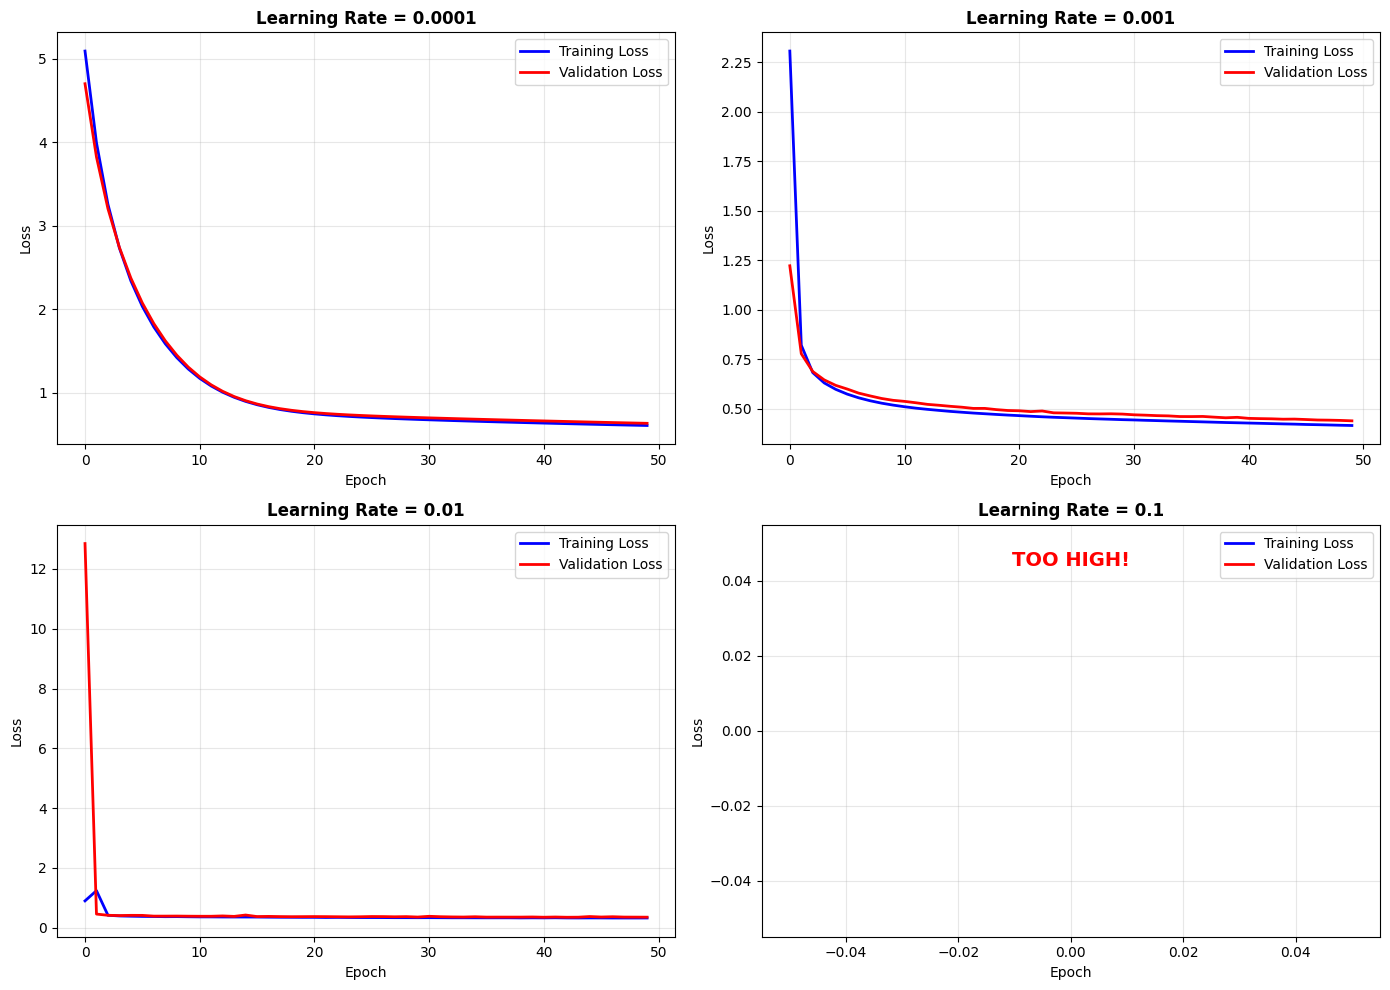


✓ Learning rate comparison complete!

Observations:
  - Too low (0.0001): Slow convergence
  - Good (0.001-0.01): Steady improvement
  - Too high (0.1): Unstable or diverging


In [68]:
# Demonstrate different learning rates
learning_rates = [0.0001, 0.001, 0.01, 0.1]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, lr in enumerate(learning_rates):
    print(f"Training with learning rate = {lr}...")
    
    model_lr = keras.models.Sequential([
        keras.layers.Dense(30, activation="relu", input_shape=X_train_scaled.shape[1:]),
        keras.layers.Dense(1)
    ])
    
    model_lr.compile(
        loss="mse",
        optimizer=keras.optimizers.SGD(learning_rate=lr)
    )
    
    history = model_lr.fit(
        X_train_scaled, y_train,
        epochs=50,
        validation_data=(X_valid_scaled, y_valid),
        verbose=0
    )
    
    # Plot
    axes[idx].plot(history.history['loss'], 'b-', label='Training Loss', linewidth=2)
    axes[idx].plot(history.history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[idx].set_xlabel('Epoch', fontsize=10)
    axes[idx].set_ylabel('Loss', fontsize=10)
    axes[idx].set_title(f'Learning Rate = {lr}', fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    
    if lr >= 0.1:
        axes[idx].text(0.5, 0.9, 'TOO HIGH!', transform=axes[idx].transAxes,
                      fontsize=14, color='red', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Learning rate comparison complete!")
print("\nObservations:")
print("  - Too low (0.0001): Slow convergence")
print("  - Good (0.001-0.01): Steady improvement")
print("  - Too high (0.1): Unstable or diverging")

### Batch Size

**Batch size** affects both training speed and model performance.

| Batch Size | Advantages | Disadvantages |
|-----------|------------|---------------|
| **Small (2-32)** | Better generalization, escape local minima | Slower, noisy gradients |
| **Medium (32-256)** | Good balance | - |
| **Large (256+)** | Faster training, efficient GPU use | May need learning rate warmup, worse generalization |

**Strategy:**
1. Try larger batches (128-256) first for speed
2. If unstable or poor performance, reduce to 32-64
3. Optimal learning rate depends on batch size

**Important**: When changing batch size, you may need to adjust the learning rate!

### Other Important Hyperparameters

**Activation Functions:**
- **Hidden layers**: ReLU (default), or SELU for deep networks
- **Output layer**: 
  - Regression: None
  - Binary classification: Sigmoid
  - Multiclass: Softmax

**Optimizer:**
- SGD is basic
- Better options: Adam, RMSprop, Nadam (covered in Chapter 11)
- Always retune learning rate when changing optimizer

**Number of Iterations:**
- Don't tune directly
- Use **early stopping** instead
- Let the model train until validation performance plateaus

**Remember**: When you modify ANY hyperparameter, the optimal learning rate may change!

---
## Key Takeaways

Let's summarize everything we've learned about Artificial Neural Networks with Keras!

### 1. 🧠 Foundation
- **ANNs are inspired by biological neurons** but have evolved beyond strict biological analogies
- **Perceptrons** are limited to linear classification problems
- **MLPs** (Multilayer Perceptrons) overcome this limitation with hidden layers
- **Backpropagation** efficiently computes gradients using reverse-mode autodiff

### 2. 🏗️ Keras APIs
Keras provides **three APIs** with different flexibility levels:

| API | Flexibility | Use Case |
|-----|------------|----------|
| **Sequential** | Low | Simple, linear stacks of layers |
| **Functional** | Medium | Complex architectures, multiple I/O |
| **Subclassing** | High | Research, dynamic models |

### 3. 🔄 Model Lifecycle
The typical workflow:
1. **Build**: Create model architecture
2. **Compile**: Configure loss, optimizer, metrics
3. **Train**: Fit model to data
4. **Evaluate**: Test on held-out data
5. **Predict**: Use for inference

### 4. 🎛️ Callbacks
Enable powerful training automation:
- **ModelCheckpoint**: Save best models automatically
- **EarlyStopping**: Prevent overfitting, save time
- **TensorBoard**: Visualize training progress
- **Custom**: Create your own logic

### 5. 📊 Visualization
- **TensorBoard** provides professional visualization
- Monitor learning curves, histograms, images, and more
- Essential for understanding training dynamics

### 6. 🎯 Architecture Guidelines

**Hidden Layers:**
- Start with 1-2 layers
- Increase until overfitting begins
- Deep networks > wide shallow networks
- Very complex tasks may need dozens/hundreds of layers

**Neurons per Layer:**
- Use uniform size across layers (modern default)
- "Stretch pants" approach: More neurons + regularization
- Typical ranges: 10-100 for most problems
- Avoid bottlenecks (too few neurons)

**General Principle**: 📈 More layers > more neurons per layer

### 7. 🔧 Hyperparameter Tuning

**Priority Order:**
1. **Learning rate** ⭐⭐⭐ (Most important!)
2. Number of hidden layers
3. Neurons per layer
4. Batch size
5. Activation functions
6. Optimizer type

**Tuning Strategies:**
- RandomizedSearchCV for exploration
- Advanced tools: Keras Tuner, Optuna, Ray Tune
- Always use early stopping
- Cloud platforms for large-scale searches

### 8. 📏 Learning Rate
- **Most critical hyperparameter**
- Optimal ≈ half of maximum stable rate
- Use learning rate finder technique
- Retune when changing any other hyperparameter

### 9. 💾 Best Practices
- **Always** save your models
- Use **early stopping** to prevent overfitting
- **Scale your features** (especially for neural networks!)
- Monitor both training and validation metrics
- Use **TensorBoard** for visualization
- Start simple, add complexity gradually

### 10. 🎓 Task-Specific Configurations

**Regression:**
- Output: Single neuron, no activation
- Loss: MSE (or MAE/Huber for outliers)

**Binary Classification:**
- Output: Single neuron, sigmoid activation
- Loss: Binary cross-entropy

**Multiclass Classification:**
- Output: One neuron per class, softmax activation
- Loss: Categorical cross-entropy (sparse or regular)

**Multilabel Classification:**
- Output: One neuron per label, sigmoid activation
- Loss: Binary cross-entropy

---

## 🚀 Next Steps

You've completed the fundamentals of Artificial Neural Networks! Future chapters will cover:

- **Chapter 11**: Training Deep Neural Networks
  - Better optimizers (Adam, RMSprop)
  - Batch normalization
  - Gradient clipping
  - Transfer learning

- **Convolutional Neural Networks (CNNs)**: For image processing
- **Recurrent Neural Networks (RNNs)**: For sequential data
- **Autoencoders**: For unsupervised learning
- **Generative Adversarial Networks (GANs)**: For generating new data

### 🎯 Practice Recommendations:
1. Build your own image classifier with different architectures
2. Experiment with hyperparameter tuning
3. Try different datasets (CIFAR-10, MNIST variants)
4. Monitor training with TensorBoard
5. Implement custom callbacks for your specific needs

**Congratulations on completing Chapter 10!** 🎉

---
## 📚 Complete Chapter Summary

This notebook covered **all major topics** from Chapter 10:

### ✅ Part 1: Foundations (Cells 1-33)
- Historical context and biological inspiration
- Perceptrons and their limitations
- Multilayer Perceptrons (MLPs)
- Backpropagation algorithm
- Activation functions (Sigmoid, Tanh, ReLU)
- MLP architectures for regression and classification

### ✅ Part 2: Keras Implementation (Cells 34-77)
- Installing and setting up TensorFlow/Keras
- Building image classifier (Fashion MNIST)
- Building regression model (California Housing)
- Functional API for complex architectures
- Wide & Deep networks
- Multiple inputs and outputs

### ✅ Part 3: Advanced Features (Cells 78-106+)
- Subclassing API for custom models
- Saving and loading models
- Callbacks (ModelCheckpoint, EarlyStopping, Custom)
- TensorBoard visualization
- Advanced logging techniques

### ✅ Part 4: Optimization & Best Practices (Current)
- Hyperparameter tuning strategies
- Architecture design guidelines
- Learning rate optimization
- Batch size considerations
- Key takeaways and next steps

---

### 🎓 What You've Learned:
- ✅ Build neural networks from scratch
- ✅ Train on real datasets
- ✅ Implement complex architectures
- ✅ Save and restore models
- ✅ Use callbacks for automation
- ✅ Visualize with TensorBoard
- ✅ Tune hyperparameters effectively
- ✅ Apply best practices

### 💪 You're Now Ready To:
- Build production-ready neural networks
- Tackle real-world ML problems
- Experiment with different architectures
- Optimize model performance
- Move on to advanced deep learning topics

**Happy Deep Learning!** 🚀🧠✨